# Fase 5b: Diagnóstico geométrico y calibración (Grid Search)

**Autor:** Andoni Cabrera Fernández

**Descripción Técnica:** En este cuaderno se procesan las distancias geométricas (EAR y MAR) extraídas en la fase anterior para implementar un sistema de diagnóstico de la fatiga. La lógica de clasificación se basa en la escala KSS y consta de:

1. **Calibración inicial:** Durante los primeros segundos de trayecto, se calcula la media ($\mu$) y la desviación estándar ($\sigma$) del EAR del conductor. Con estos estadísticos se define un umbral dinámico de oclusión palpebral, asegurado mediante un límite inferior estricto ($EAR_{th} \ge 0.18$) para prevenir errores de calibración.
2. **Diagnóstico multiclase:** Se calcula el PERCLOS (para detectar somnolencia severa, clase 10) y la duración máxima de los bostezos (para identificar fatiga o baja vigilancia, clase 5).

Se emplea un algoritmo de búsqueda en cuadrícula (*Grid Search*) para obtener la combinación óptima de hiperparámetros. El rendimiento se evalúa frente a distintas frecuencias de muestreo (30, 15, 5 y 1 FPS), comparando la métrica F1-Score con la Exactitud (Accuracy) para evaluar la viabilidad del despliegue en hardware de recursos limitados.

In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuración del entorno y carga de datos
Importación de librerías y carga de los archivos con los datos geométricos (EAR y MAR) procesados a 30, 15, 5 y 1 FPS.

In [2]:
ruta_base = '/content/drive/MyDrive/TFG_Fatiga_Colab/PKL_GEOMETRIA/'
print("Iniciando carga de archivos con datos geométricos (EAR/MAR)...")

espacio_fps = [30, 15, 5, 1]
datos_dict = {}

for fps in espacio_fps:
    nombre_archivo = f'geometria_{fps}fps.pkl'
    ruta_completa = os.path.join(ruta_base, nombre_archivo)

    if os.path.exists(ruta_completa):
        with open(ruta_completa, 'rb') as f:
            df = pickle.load(f)
            if isinstance(df, list):
                df = pd.DataFrame(df)
            datos_dict[fps] = df
        print(f" -> Cargado con éxito: {nombre_archivo} ({len(df)} registros procesados)")
    else:
        print(f" -> Advertencia: No se encontró el archivo {nombre_archivo} en {ruta_base}")

Iniciando carga de archivos con datos geométricos (EAR/MAR)...
 -> Cargado con éxito: geometria_30fps.pkl (3043591 registros procesados)
 -> Cargado con éxito: geometria_15fps.pkl (1521830 registros procesados)
 -> Cargado con éxito: geometria_5fps.pkl (507334 registros procesados)
 -> Cargado con éxito: geometria_1fps.pkl (101538 registros procesados)


## 2. Metodología de diagnóstico
Se define la función de evaluación por vídeo. Tras el período de calibración inicial, se calcula el umbral dinámico de EAR, el PERCLOS global y la duración máxima de bostezo. Finalmente, se clasifica el nivel de vigilancia del conductor aplicando el árbol de decisión jerárquico.

In [3]:
def evaluar_video_geometrico(df_video, fps, warmup_sec, p_mod, p_sev, mar_th, b_sec, sigma_mult, ear_min):
    df_video = df_video.sort_values('frame_idx').copy()
    total_frames = len(df_video)
    if total_frames == 0:
        return 0

    # 1. Calibración biométrica asíncrona (Warm-Up)
    frames_warmup = min(int(warmup_sec * fps), total_frames)
    ear_calibracion = df_video['ear'].iloc[:frames_warmup]
    mu_ear = ear_calibracion.mean()
    sigma_ear = ear_calibracion.std()

    umbral_ear_dinamico = max(mu_ear - (sigma_mult * sigma_ear), ear_min)

    # 2. Extracción de biomarcadores globales
    es_cerrado = df_video['ear'] < umbral_ear_dinamico
    perclos_global = es_cerrado.sum() / total_frames

    es_bostezo = df_video['mar'] > mar_th
    rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()
    segundos_max_bostezo = (rachas.max() / fps) if not rachas.empty else 0

    # 3. Árbol de Decisión Clínico (Doble Umbral PERCLOS)
    if perclos_global >= p_sev:
        return 10
    elif perclos_global >= p_mod or segundos_max_bostezo >= b_sec:
        return 5
    else:
        return 0

def evaluar_dataset_geometrico(df, fps, warmup_sec, p_mod, p_sev, mar_th, b_sec, sigma_mult, ear_min):
    y_true, y_pred = [], []
    lista_videos = df['video'].unique()
    for vid in lista_videos:
        df_vid = df[df['video'] == vid]
        clase_real = df_vid['clase_real'].iloc[0]

        prediccion = evaluar_video_geometrico(
            df_vid, fps, warmup_sec, p_mod, p_sev, mar_th, b_sec, sigma_mult, ear_min
        )
        y_true.append(clase_real)
        y_pred.append(prediccion)

    return y_true, y_pred

## 3. Optimización de hiperparámetros (Grid Search)
Implementación de la búsqueda exhaustiva de hiperparámetros adaptada a la geometría de la malla facial. Se evalúan distintas combinaciones para acotar los umbrales de MAR y las variables temporales, buscando maximizar el F1-Score (reducción de falsos negativos) y la Exactitud (reducción de falsas alarmas).

In [4]:
print("Iniciando búsqueda paramétrica (Grid Search) con almacenamiento en caché...")
espacio_fps = [30, 15, 5, 1]
espacio_warmup = [40]
espacio_p_mod = [0.05, 0.10]
espacio_p_sev = [0.15, 0.20]
espacio_mar = [0.60, 0.70, 0.80]
espacio_b_sec = [1.0, 1.5, 2.0]
espacio_sigma_mult = [2.0, 2.5, 3.0]
espacio_ear_min = [0.16, 0.18, 0.20]

mejores_modelos_f1 = {}
mejores_modelos_acc = {}
inicio_global = time.time()

for fps in espacio_fps:
    if fps not in datos_dict:
        continue

    df_actual = datos_dict[fps]
    lista_videos = df_actual['video'].unique()

    # CAMBIO CRÍTICO: Renombramos a v2 para forzar la creación de una nueva caché con los nuevos rangos MAR
    ruta_cache = os.path.join(ruta_base, f'cache_geom_{fps}fps_global_v2.pkl')

    if os.path.exists(ruta_cache):
        with open(ruta_cache, 'rb') as f:
            cache_guardada = pickle.load(f)
        precomp_vids = cache_guardada['precomp_vids']
        clases_reales = cache_guardada['clases_reales']
    else:
        precomp_vids = {}
        clases_reales = {}

        for vid in lista_videos:
            df_vid = df_actual[df_actual['video'] == vid].sort_values('frame_idx')
            clases_reales[vid] = df_vid['clase_real'].iloc[0]
            frames_warmup = min(int(40 * fps), len(df_vid))
            ear_calib = df_vid['ear'].iloc[:frames_warmup]

            precomp_vids[vid] = {
                'ear': df_vid['ear'].values,
                'mu_ear': ear_calib.mean(),
                'sigma_ear': ear_calib.std(),
                'bostezos_mar': {}
            }
            for m_th in espacio_mar:
                es_bostezo = df_vid['mar'] > m_th
                rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()
                precomp_vids[vid]['bostezos_mar'][m_th] = (rachas.max() / fps) if not rachas.empty else 0

        with open(ruta_cache, 'wb') as f:
            pickle.dump({'precomp_vids': precomp_vids, 'clases_reales': clases_reales}, f)

    mejor_f1, mejor_acc = -1, -1
    config_f1, config_acc = {}, {}

    print(f"[+] Fase 2: Ejecutando combinaciones clínicas para {fps} FPS...")
    for p_m in espacio_p_mod:
        for p_s in espacio_p_sev:
            for m_th in espacio_mar:
                for b_s in espacio_b_sec:
                    for s_mult in espacio_sigma_mult:
                        for e_min in espacio_ear_min:

                            y_true, y_pred = [], []
                            for vid in lista_videos:
                                v_data = precomp_vids[vid]
                                umbral_ear = max(v_data['mu_ear'] - (s_mult * v_data['sigma_ear']), e_min)

                                es_cerrado = (v_data['ear'] < umbral_ear)
                                perclos_global = es_cerrado.mean()
                                segundos_max_bostezo = v_data['bostezos_mar'][m_th]

                                if perclos_global >= p_s: pred = 10
                                elif perclos_global >= p_m or segundos_max_bostezo >= b_s: pred = 5
                                else: pred = 0

                                y_true.append(clases_reales[vid])
                                y_pred.append(pred)

                            macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
                            acc = accuracy_score(y_true, y_pred)

                            if macro_f1 > mejor_f1:
                                mejor_f1 = macro_f1
                                config_f1 = {'WarmUp': 40, 'P_Mod': p_m, 'P_Sev': p_s, 'MAR': m_th, 'B_Sec': b_s, 'Sigma': s_mult, 'EAR_Min': e_min, 'Accuracy': acc, 'Macro_F1': macro_f1}
                            if acc > mejor_acc:
                                mejor_acc = acc
                                config_acc = {'WarmUp': 40, 'P_Mod': p_m, 'P_Sev': p_s, 'MAR': m_th, 'B_Sec': b_s, 'Sigma': s_mult, 'EAR_Min': e_min, 'Accuracy': acc, 'Macro_F1': macro_f1}

    mejores_modelos_f1[fps] = config_f1
    mejores_modelos_acc[fps] = config_acc
    print(f"[!] ÉXITO: Búsqueda completada para el entorno de {fps} FPS.")

print(f"\n>>> Grid Search Global finalizado en {time.time() - inicio_global:.2f} segundos.")

Iniciando búsqueda paramétrica (Grid Search) con almacenamiento en caché...
[+] Fase 2: Ejecutando combinaciones clínicas para 30 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 30 FPS.
[+] Fase 2: Ejecutando combinaciones clínicas para 15 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 15 FPS.
[+] Fase 2: Ejecutando combinaciones clínicas para 5 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 5 FPS.
[+] Fase 2: Ejecutando combinaciones clínicas para 1 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 1 FPS.

>>> Grid Search Global finalizado en 11.78 segundos.


## 4. Reporte comparativo de rendimiento (F1-Score frente a Exactitud)

In [5]:
print("-" * 110)
print("RESULTADOS PRIORIZANDO F1-SCORE (Prioridad: Evitar Falsos Negativos)")
print("-" * 110)
for fps, top in mejores_modelos_f1.items():
    print(f"[{fps} FPS] F1: {top['Macro_F1']:.4f} | Acc: {top['Accuracy']:.4f} -> P_Mod: {top['P_Mod']} | P_Sev: {top['P_Sev']} | MAR: {top['MAR']} | B_sec: {top['B_Sec']}s | Sig: {top['Sigma']}x")

print("\n" + "-" * 110)
print("RESULTADOS PRIORIZANDO ACCURACY (Prioridad: Evitar Falsas Alarmas)")
print("-" * 110)
for fps, top in mejores_modelos_acc.items():
    print(f"[{fps} FPS] Acc: {top['Accuracy']:.4f} | F1: {top['Macro_F1']:.4f} -> P_Mod: {top['P_Mod']} | P_Sev: {top['P_Sev']} | MAR: {top['MAR']} | B_sec: {top['B_Sec']}s | Sig: {top['Sigma']}x")
print("-" * 110)

--------------------------------------------------------------------------------------------------------------
RESULTADOS PRIORIZANDO F1-SCORE (Prioridad: Evitar Falsos Negativos)
--------------------------------------------------------------------------------------------------------------
[30 FPS] F1: 0.3100 | Acc: 0.5167 -> P_Mod: 0.1 | P_Sev: 0.15 | MAR: 0.8 | B_sec: 1.5s | Sig: 2.0x
[15 FPS] F1: 0.3100 | Acc: 0.5167 -> P_Mod: 0.1 | P_Sev: 0.15 | MAR: 0.8 | B_sec: 1.5s | Sig: 2.0x
[5 FPS] F1: 0.3085 | Acc: 0.5056 -> P_Mod: 0.05 | P_Sev: 0.15 | MAR: 0.8 | B_sec: 1.5s | Sig: 3.0x
[1 FPS] F1: 0.3242 | Acc: 0.5333 -> P_Mod: 0.05 | P_Sev: 0.15 | MAR: 0.8 | B_sec: 1.5s | Sig: 3.0x

--------------------------------------------------------------------------------------------------------------
RESULTADOS PRIORIZANDO ACCURACY (Prioridad: Evitar Falsas Alarmas)
--------------------------------------------------------------------------------------------------------------
[30 FPS] Acc: 0.5167 | 

## 5. Rendimiento frente a la resolución temporal

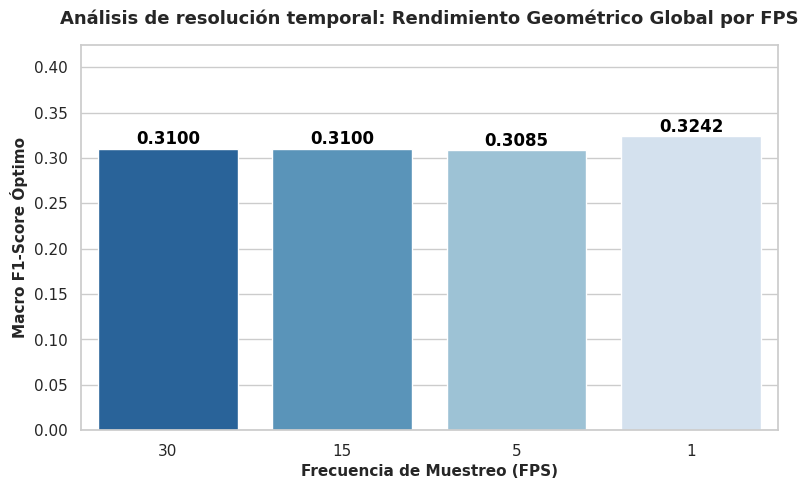

In [6]:
# Graficaremos la máxima capacidad predictiva (F1-Score) por resolución
datos_grafico = [{'FPS': fps, 'Max_F1': config['Macro_F1']} for fps, config in mejores_modelos_f1.items()]
df_grafico = pd.DataFrame(datos_grafico)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
grafico = sns.barplot(x='FPS', y='Max_F1', data=df_grafico, palette='Blues_r', order=[30, 15, 5, 1])

for index, row in enumerate(df_grafico.itertuples()):
    grafico.text(index, row.Max_F1 + 0.005, f"{row.Max_F1:.4f}", color='black', ha="center", fontweight='bold')

plt.title('Análisis de resolución temporal: Rendimiento Geométrico Global por FPS', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Frecuencia de Muestreo (FPS)', fontsize=11, fontweight='bold')
plt.ylabel('Macro F1-Score Óptimo', fontsize=11, fontweight='bold')
plt.ylim(0, max(df_grafico['Max_F1']) + 0.1)
plt.show()

## 6. Ajuste paramétrico a 5 FPS
Tras confirmar que la frecuencia de 5 FPS proporciona un equilibrio adecuado entre rendimiento y coste computacional, se aísla este conjunto de datos para ejecutar una búsqueda con mayor granularidad y fijar los hiperparámetros definitivos del modelo geométrico.

In [7]:
print("Iniciando búsqueda fina a 5 FPS...")

espacio_warmup_fino = [40]
espacio_p_mod_fino = [0.03, 0.04, 0.05]
espacio_p_sev_fino = [0.14, 0.15, 0.16]
espacio_mar_fino = [0.85, 0.90, 0.95]
espacio_b_sec_fino = [1.2, 1.3, 1.4]
espacio_sigma_mult_fino = [2.8, 2.9, 3.0, 3.1]
espacio_ear_min_fino = [0.19, 0.20, 0.21, 0.22]

df_5fps = datos_dict[5]
lista_videos = df_5fps['video'].unique()

# --- CACHÉ EN RAM PARA ACELERAR EL PROCESO ---
precomp_fino = {}
clases_reales = {}

for vid in lista_videos:
    df_vid = df_5fps[df_5fps['video'] == vid].sort_values('frame_idx')
    clases_reales[vid] = df_vid['clase_real'].iloc[0]

    frames_warmup = min(int(40 * 5), len(df_vid))
    ear_calib = df_vid['ear'].iloc[:frames_warmup]

    precomp_fino[vid] = {
        'ear': df_vid['ear'].values,
        'mu_ear': ear_calib.mean(),
        'sigma_ear': ear_calib.std(),
        'bostezos_mar': {},
        'total_frames': len(df_vid['ear'])
    }
    for m_th in espacio_mar_fino:
        es_bostezo = pd.Series(df_vid['mar'].values > m_th)
        rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()
        precomp_fino[vid]['bostezos_mar'][m_th] = (rachas.max() / 5) if not rachas.empty else 0

mejor_f1_fino = -1
config_fina = {}
inicio_fino = time.time()

for wu in espacio_warmup_fino:
    for p_m in espacio_p_mod_fino:
        for p_s in espacio_p_sev_fino:
            for m_th in espacio_mar_fino:
                for b_s in espacio_b_sec_fino:
                    for s_mult in espacio_sigma_mult_fino:
                        for e_min in espacio_ear_min_fino:

                            y_true, y_pred = [], []
                            for vid in lista_videos:
                                v_data = precomp_fino[vid]
                                umbral_ear = max(v_data['mu_ear'] - (s_mult * v_data['sigma_ear']), e_min)

                                es_cerrado = (v_data['ear'] < umbral_ear)
                                perclos_global = es_cerrado.sum() / v_data['total_frames']
                                segundos_max_bostezo = v_data['bostezos_mar'][m_th]

                                if perclos_global >= p_s: pred = 10
                                elif perclos_global >= p_m or segundos_max_bostezo >= b_s: pred = 5
                                else: pred = 0

                                y_true.append(clases_reales[vid])
                                y_pred.append(pred)

                            macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
                            acc = accuracy_score(y_true, y_pred)

                            if macro_f1 > mejor_f1_fino:
                                mejor_f1_fino = macro_f1
                                config_fina = {
                                    'WarmUp': wu, 'P_Mod': p_m, 'P_Sev': p_s, 'MAR': m_th,
                                    'B_Sec': b_s, 'Sigma': s_mult, 'EAR_Min': e_min,
                                    'Accuracy': acc, 'Macro_F1': macro_f1
                                }

print(f"Búsqueda fina finalizada en {time.time() - inicio_fino:.2f} segundos.\n")
print("-" * 75)
print("HIPERPARÁMETROS GEOMÉTRICOS DEFINITIVOS (5 FPS)")
print("-" * 75)
print(f"F1-Score: {config_fina['Macro_F1']*100:.2f}% | Accuracy: {config_fina['Accuracy']*100:.2f}%")
print(f"-> Warm-Up:         {config_fina['WarmUp']}s")
print(f"-> Desviación (σ):  {config_fina['Sigma']}x")
print(f"-> P_Mod (Clase 5): {config_fina['P_Mod']}")
print(f"-> P_Sev (Clase 10):{config_fina['P_Sev']}")
print(f"-> Umbral MAR:      {config_fina['MAR']}")
print(f"-> Bostezo Sec:     {config_fina['B_Sec']}s")
print("-" * 75)

Iniciando búsqueda fina a 5 FPS...
Búsqueda fina finalizada en 4.90 segundos.

---------------------------------------------------------------------------
HIPERPARÁMETROS GEOMÉTRICOS DEFINITIVOS (5 FPS)
---------------------------------------------------------------------------
F1-Score: 33.65% | Accuracy: 55.00%
-> Warm-Up:         40s
-> Desviación (σ):  3.0x
-> P_Mod (Clase 5): 0.04
-> P_Sev (Clase 10):0.15
-> Umbral MAR:      0.9
-> Bostezo Sec:     1.3s
---------------------------------------------------------------------------


## 7. Evaluación diagnóstica final y matriz de confusión
Aplicación de los hiperparámetros óptimos calculados para 5 FPS sobre el conjunto de validación y generación de la matriz de confusión y el reporte de clasificación final.

Generando diagnóstico final a 5 FPS con parámetros Fine-Tuned (Global)...


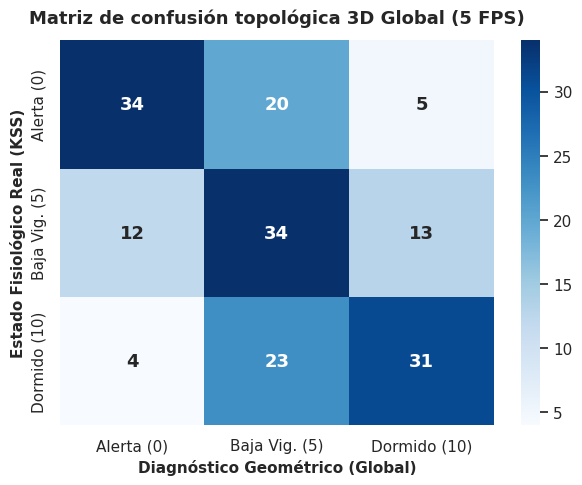


REPORTE CLÍNICO FINAL DE CLASIFICACIÓN (5 FPS)
               precision    recall  f1-score   support

   Alerta (0)       0.68      0.58      0.62        59
Baja Vig. (5)       0.44      0.58      0.50        59
 Dormido (10)       0.58      0.53      0.56        58

    micro avg       0.55      0.56      0.56       176
    macro avg       0.57      0.56      0.56       176
 weighted avg       0.57      0.56      0.56       176



In [8]:
opt_fps = 5

print(f"Generando diagnóstico final a {opt_fps} FPS con parámetros Fine-Tuned (Global)...")

y_true_opt, y_pred_opt = evaluar_dataset_geometrico(
    df_5fps, fps=opt_fps,
    warmup_sec=config_fina['WarmUp'],
    p_mod=config_fina['P_Mod'],
    p_sev=config_fina['P_Sev'],
    mar_th=config_fina['MAR'],
    b_sec=config_fina['B_Sec'],
    sigma_mult=config_fina['Sigma'],
    ear_min=config_fina['EAR_Min']
)

cm = confusion_matrix(y_true_opt, y_pred_opt, labels=[0, 5, 10])
etiquetas_clinicas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas_clinicas,
            yticklabels=etiquetas_clinicas,
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Matriz de confusión topológica 3D Global ({opt_fps} FPS)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Estado Fisiológico Real (KSS)', fontsize=11, fontweight='bold')
plt.xlabel('Diagnóstico Geométrico (Global)', fontsize=11, fontweight='bold')
plt.show()

print("\n" + "="*55)
print(f"REPORTE CLÍNICO FINAL DE CLASIFICACIÓN ({opt_fps} FPS)")
print("="*55)
print(classification_report(y_true_opt, y_pred_opt, labels=[0, 5, 10], target_names=etiquetas_clinicas))

## 8. Análisis Estadístico Exploratorio (EDA)
Análisis de la distribución de densidad de los indicadores biométricos (EAR y MAR) en función de la clase clínica real. Este estudio permite validar si las métricas puramente geométricas reducen el solapamiento entre clases y mejoran la generalización en comparación con la evaluación de probabilidad extraída directamente por la red convolucional.

Iniciando Análisis Exploratorio de Datos (EDA)...

--- 1. RESUMEN ESTADÍSTICO POR ESTADO (KSS) ---

>> Análisis de: EAR
                  count    mean     std     min     25%     50%     75%  \
Estado                                                                    
Alerta (0)     168442.0  0.2787  0.0437  0.0134  0.2577  0.2803  0.3050   
Baja Vig. (5)  165522.0  0.2686  0.0536  0.0127  0.2425  0.2732  0.3024   
Dormido (10)   165849.0  0.2455  0.0644  0.0119  0.2217  0.2578  0.2885   

                  max  
Estado                 
Alerta (0)     0.4375  
Baja Vig. (5)  0.4865  
Dormido (10)   0.5344  

>> Análisis de: MAR
                  count    mean     std     min     25%     50%     75%  \
Estado                                                                    
Alerta (0)     168442.0  0.5952  0.1115  0.1162  0.5283  0.6033  0.6653   
Baja Vig. (5)  165522.0  0.5978  0.1398  0.0687  0.5178  0.5945  0.6649   
Dormido (10)   165849.0  0.6003  0.1377  0.0864  0.5252  0.5986

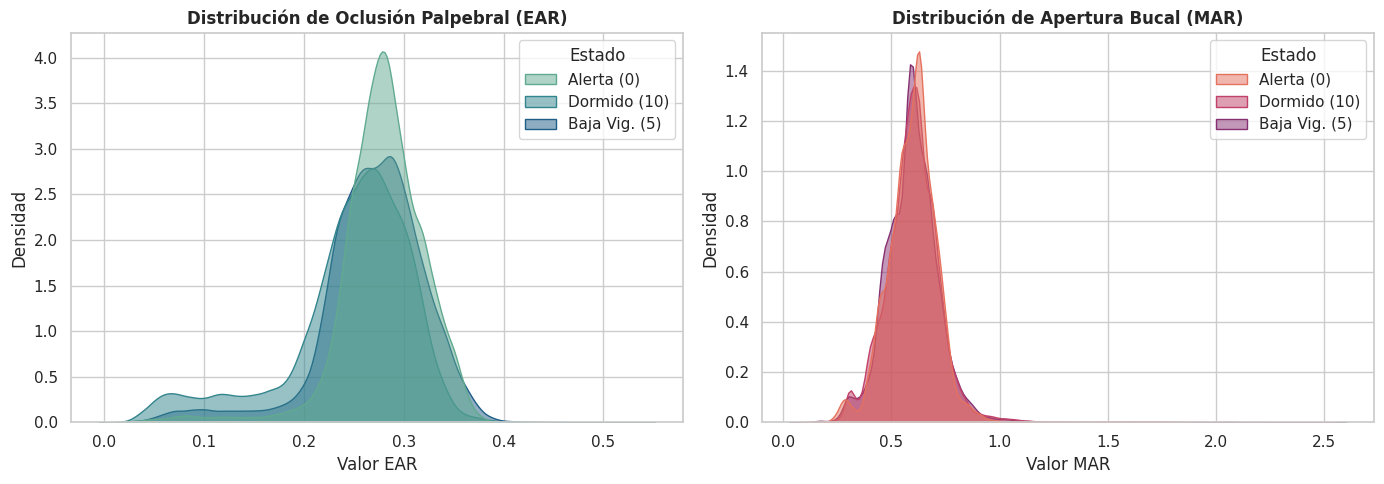


Generando serie temporal para el vídeo analizado: 01_0.mov...


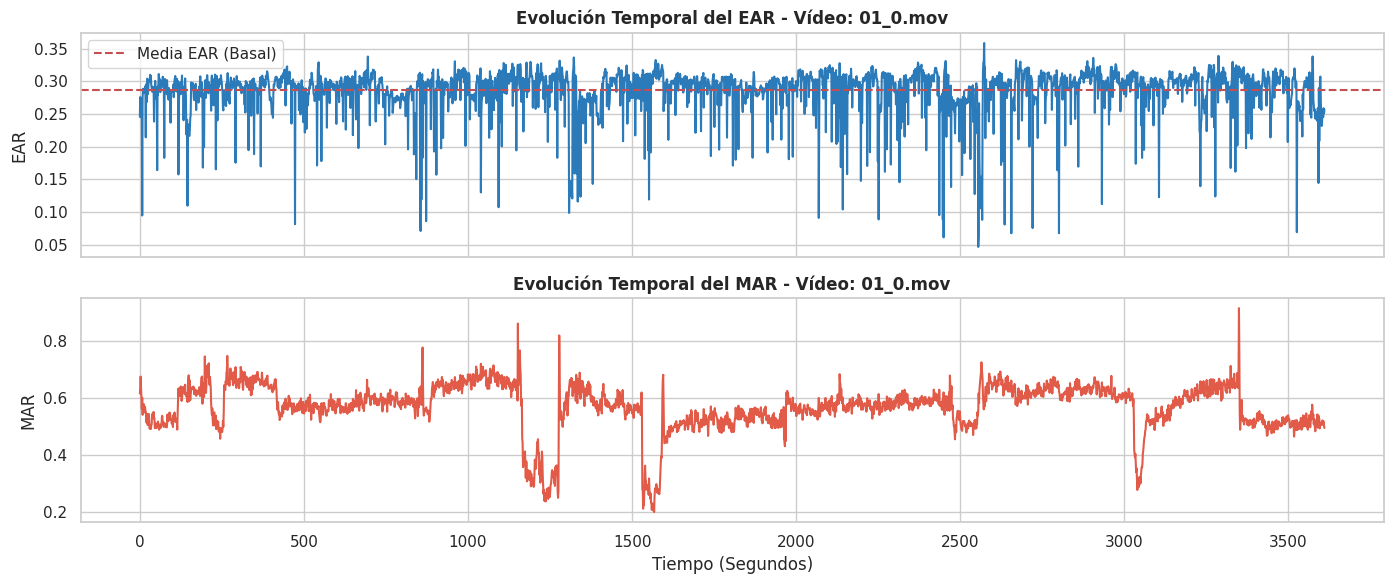


Reporte exploratorio Geometría 3D finalizado. Listo para exportar a la memoria.


In [9]:
print("Iniciando Análisis Exploratorio de Datos (EDA)...")

# 1. Carga de datos extraída directamente del diccionario de la Celda 4
df_eda = datos_dict[5].copy()

# Mapeo de etiquetas para las gráficas
mapa_clases = {0: 'Alerta (0)', 5: 'Baja Vig. (5)', 10: 'Dormido (10)'}
df_eda['Estado'] = df_eda['clase_real'].map(mapa_clases)

print("\n--- 1. RESUMEN ESTADÍSTICO POR ESTADO (KSS) ---")
for biometria in ['ear', 'mar']:
    print(f"\n>> Análisis de: {biometria.upper()}")
    resumen_clase = df_eda.groupby('Estado')[biometria].describe().round(4)
    print(resumen_clase)

# 2. DISTRIBUCIÓN DE BIOMARCADORES (KDE Plots)
print("\nGenerando gráficas de distribución de la telemetría 3D...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfica EAR
sns.kdeplot(data=df_eda, x="ear", hue="Estado", fill=True, palette="crest", ax=axes[0], alpha=0.5)
axes[0].set_title('Distribución de Oclusión Palpebral (EAR)', fontweight='bold')
axes[0].set_xlabel('Valor EAR')
axes[0].set_ylabel('Densidad')

# Gráfica MAR
sns.kdeplot(data=df_eda, x="mar", hue="Estado", fill=True, palette="flare", ax=axes[1], alpha=0.5)
axes[1].set_title('Distribución de Apertura Bucal (MAR)', fontweight='bold')
axes[1].set_xlabel('Valor MAR')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

# 3. ANÁLISIS DE SERIE TEMPORAL (Elegimos el primer vídeo disponible)
video_muestra = df_eda['video'].iloc[0]
df_muestra = df_eda[df_eda['video'] == video_muestra].sort_values('frame_idx')

# Convertir frames a segundos reales (a 5 FPS, 1 frame = 0.2s)
df_muestra['segundos'] = df_muestra['frame_idx'] / 5.0

print(f"\nGenerando serie temporal para el vídeo analizado: {video_muestra}...")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Evolución del EAR
sns.lineplot(data=df_muestra, x='segundos', y='ear', ax=axes[0], color='#2b7bba', linewidth=1.5)
axes[0].axhline(y=df_muestra['ear'].mean(), color='r', linestyle='--', label='Media EAR (Basal)')
axes[0].set_title(f'Evolución Temporal del EAR - Vídeo: {video_muestra}', fontweight='bold')
axes[0].set_ylabel('EAR')
axes[0].legend()

# Evolución del MAR
sns.lineplot(data=df_muestra, x='segundos', y='mar', ax=axes[1], color='#e25a48', linewidth=1.5)
axes[1].set_title(f'Evolución Temporal del MAR - Vídeo: {video_muestra}', fontweight='bold')
axes[1].set_xlabel('Tiempo (Segundos)')
axes[1].set_ylabel('MAR')

plt.tight_layout()
plt.show()

print("\nReporte exploratorio Geometría 3D finalizado. Listo para exportar a la memoria.")